# PhishGuard AI - 04 Model Evaluation & Interpretability
**Comparative Analysis: Accuracy, Precision, Recall, F1, ROC-AUC, and Feature Importances**

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from src.config import (
    DEFAULT_PROCESSED_DATASET_CSV,
    LOGISTIC_REGRESSION_PATH,
    DECISION_TREE_PATH,
    RANDOM_FOREST_PATH,
    SCALER_PATH
)
from src.feature_extraction import FEATURE_NAMES

# Load artifacts
lr = joblib.load(LOGISTIC_REGRESSION_PATH)
dt = joblib.load(DECISION_TREE_PATH)
rf = joblib.load(RANDOM_FOREST_PATH)
scaler = joblib.load(SCALER_PATH)

df = pd.read_csv(DEFAULT_PROCESSED_DATASET_CSV)
from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    df[FEATURE_NAMES].values, df['target_label'].values, test_size=0.20, random_state=42, stratify=df['target_label'].values
)
X_test_scaled = scaler.transform(X_test)

## 1. Metrics Comparison Table

In [2]:
models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "Random Forest": (rf, X_test)
}

rows = []
for name, (m, data) in models.items():
    preds = m.predict(data)
    proba = m.predict_proba(data)[:, 1] if hasattr(m, "predict_proba") else preds
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4)
    })

results_df = pd.DataFrame(rows)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0


## 2. Confusion Matrices

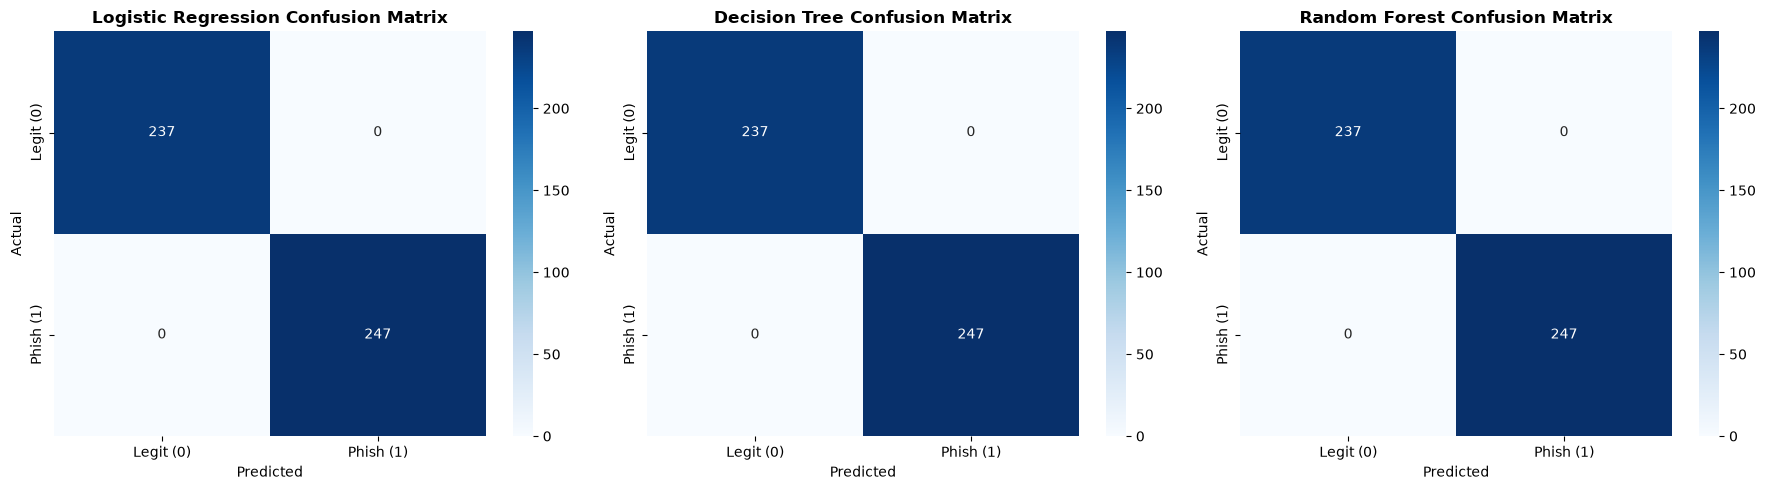

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, (m, data)) in enumerate(models.items()):
    preds = m.predict(data)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=["Legit (0)", "Phish (1)"], yticklabels=["Legit (0)", "Phish (1)"])
    axes[idx].set_title(f"{name} Confusion Matrix", fontweight="bold")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 3. Random Forest Feature Importance

C:\Users\mubas\AppData\Local\Temp\ipykernel_22300\2360358592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, palette="viridis")


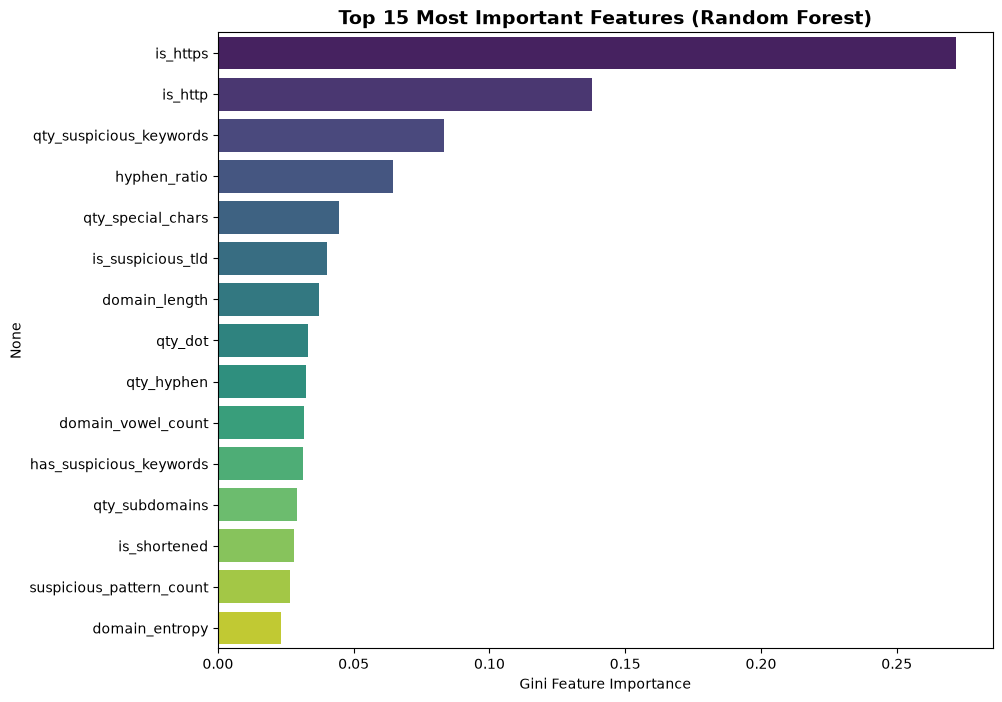

In [4]:
rf_importances = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, palette="viridis")
plt.title("Top 15 Most Important Features (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Gini Feature Importance")
plt.show()